# Week 7 - Particle Swarm Optimisation

In this week's lectures we've looked at swarm intelligence, and in particular _particle swarm optimisation_ (PSO). This notebook will guide you through the implementation of a simple PSO algorithm, which you will use to solve two _benchmark_ problems.

As discussed in the lecture, a benchmark problem is a mathematical function that has a known optimum (in these cases, a minimum). You will implement the algorithm, and then run an experiment to verify that the algorithm converges in both cases.

You are provided with an implementation of the _Sphere_ and _Rastrigin_ functions, which are defined as follows

Sphere:

$$
f(\mathbf{x}) = \sum^D_{d=1}x^2.
$$

Rastrigin:

$$
f(\mathbf{x}) = AD + \sum^D_{d=1}\left[x^2_i-A\cos(2\pi x_i)\right].
$$

Limits for decision variables in both cases should be -5.12 and 5.12 in all dimensions. For Rastrigin, $A=10$.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
def sphere(x):
    """
    The Sphere problem. Takes a solution (a numpy array of floats) and returns a
    single objective function value.
    """
    return (x**2).sum()


def rastrigin(x):
    """
    The Rastrigin problem. Takes a solution (a numpy array of floats) and returns a
    single objective function value.
    """
    A = 10
    return A*x.shape[0] + (x**2 - A*np.cos(2*np.pi*x)).sum()

In both cases, the optimum solution is the vector of zeros. We can therefore test the function implementation to ensure that this is the result we get. Using Python's __assert__ function, no news is good news: we will only receive output if the assertion fails -- so, in this case, if the optimum point is not zero.

In [3]:
x = np.zeros(10)
assert sphere(x) == 0
assert rastrigin(x) == 0

## Update the position of a particle
From the lecture, you will recall that there are two aspects to updating a particle's position: first the __velocity__ is updated, and then the __new position__ is calculated from it. The velocity is updated with

$$
v_{ij}(t+1) = v_{ij} + c_1 \times z_1 \times (p_{ij}-x_{ij}) + c_2\times z_2\times (g_j-x_{ij}),
$$

where
* $c_1$ and $c_2$ are constants -- control the weighting between personal and global experience
* $z_1,z_2\sim U(0,1)$ are two different draws from the uniform distribution between 0 and 1 (prevents premature convergence)
* $i$ indicates the particle and $j$ indicates the dimension
* $p_{ij}$ is the particle's best position (on dimension $j$) -- draws a particle back towards the fittest areas of the landscape they have encountered
* $g_j$ is the population's best position (on dimension $j$) -- enables the experience of the whole swarm to guide the particle

### Exercise 1

Implement a function that takes a particle, it's current velocity, local best, global best, and the c1 and c2 parameters, and computes the new velocity and new solution.

A skeleton function is provided that you should complete. I have set the _xp_ and _newVelocity_ variables to _None_ so that you can see what is to be returned (that's important for the next part). Your completed function should return actual values for these variables.

In [19]:
def updatePosition(x, velocity, localX, globalX, c1, c2):
    z1, z2 = np.random.rand(2)
    newVelocity = velocity + c1*z1*(localX-x) + c2*z2*(globalX-x)
    return np.clip(x + newVelocity, -5.12, 5.12), newVelocity

## Implement the PSO algorithm
Having implemented the particle update, you can implement the overall PSO algorithm by incorporating _updatePosition_ within a loop and doing some house-keeping to maintain local and global bests.

Here is the algorithm:

1. Initialise a random swarm ($N\times D$) and evaluate them against the objective function provided.
2. Initialise the local best by copying the swarm and objective values (hint: I have my swarm as a $N\times D$ Numpy array, and my objective values are in a $N$-dimensional Numpy array - thus, _X[i]_ is the $i$-th element of the swarm, and _y[i]_ is its objective value).
3. Initialise the global best by finding the best member of the swarm. Take a copy of that best member, as well as its objective value.
4. Initialise the velocities (hint: I used uniform random values between -1 and 1).
5. Initialise a list in which to hold all of the global bests throughout the evolution (so that we can confirm the algorithm is converging).
6. Repeat for _generations_ generations:
    1. Use _updatePosition_ to update the particle's position. Then evaluate it's quality with the objective function.
    2. If the particle's new position is better then its current local best, update the local best to the new position.
    3. If the particle's new position is better then the global best, update the global best to the new position.
    4. Add the global best to the global best list.
7. Return the list of global bests for the whole optimisation run, the global best, and it's objective value.

### Exercise 2
Implement the PSO algorithm within the skeleton _pso_ algorithm provided.

In [47]:
def pso(problem, N, D, generations, c1=0.5, c2=0.5):
    """
    Parameters:
     - problem: the function to be optimised.
     - N: swarm size
     - D: the size of a solution (the number of elements in the vector).
     - c1: the c1 parameter (default 0.5).
     - c2: the c2 parameter (default 0.5).
    """
    # Initialise a random swarm and evaluate the solutions using the problem provided.
    X = np.random.uniform(-5.12, 5.12, (N,D))
    y = np.array([problem(X[i]) for i in range(N)])

    # Initialise the local bests.
    localX = X.copy()
    localY = y.copy()

    # Initialise the global best.
    idx = y.argmin()
    globalX = X[idx].copy()
    globalY = y[idx].copy()

    # Initialise the starting weights.
    velocities = np.random.uniform(-1, 1, (N, D))

    # Track globals.
    globalYs = [globalY]

    for gen in range(generations):
        # Update the position of each swarm member, then evaluate its new objective
        # value, and update the local and global bests.
        for i in range(N):
            X[i], velocities[i] = updatePosition(X[i], velocities[i], localX[i], globalX, c1, c2)
            y[i] = problem(X[i])

            if y[i] < localY[i]:
                # Update the local best and now check the global best.
                localX[i] = X[i]
                localY[i] = y[i]

            if y[i] < globalY:
                globalX = X[i]
                globalY = y[i]

        globalYs.append(globalY)

    # Return the final solution set.
    return globalYs, globalX, globalY

## Analysing the execution

We need to analyse the algorithm as it executes to confirm that it converges. To do this, we need to observe its execution over repeated runs. We will capture the global best across the optimiser's execution so that we can view it converging (or not) over time.

Once we've captured the data, we will produce a graph to display the results visually.

I ran the code using a swarm size of 10, optimising 4-dimensional problems with 1,000 generations.

### Exercise 3

Complete the function _experiment_ so that it calls the _pso_ algorithm multiple (_nruns_) times. Capture the list of global variables over time __for each execution___ and return this as a Numpy array (hint: I return a Numpy array that is $K\times G$, where $K$ is the number of repeats and $G$ is the number of generations run in each execution.

In [53]:
def experiment(nruns, problem, c1, c2):
    results = []
    for i in range(nruns):
        np.random.seed(i)
        globalYs, globalX, globalY = pso(problem, 10, 4, 1000, c1=c1, c2=c2)
        results.append(globalYs)

    results = np.array(results)
    return results

### Exercise 4

Call the _experiment_ function and capture the results array returned. Use it to plot a graph so that generations are on the $x$-axis, fitness is on the $y$-axis, and the __average__ global best at each generation is shown. You *should* see this curve decrease over time.

Run it for the following configurations:
 * $c_1=0.2$ and $c_2=0.8$.
 * $c_1=0.8$ and $c_2=0.2$.

Run this experiment for __both__ the _Sphere_ and _Rastrigin_ functions. Which configuration converges faster for each problem?

[]

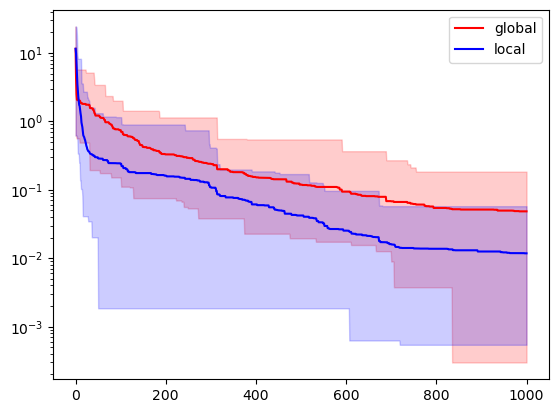

In [54]:
results1 = experiment(31, sphere, 0.2, 0.8)
plt.plot(results1.mean(axis=0), "r", label="global")
plt.fill_between(np.arange(results1.shape[1]), np.min(results1, axis=0), np.max(results1, axis=0), color="r", alpha=0.2)

results2 = experiment(31, sphere, 0.8, 0.2)
plt.plot(results2.mean(axis=0), "b", label="local")
plt.fill_between(np.arange(results2.shape[1]), np.min(results2, axis=0), np.max(results2, axis=0), color="b", alpha=0.2)

plt.legend()
plt.semilogy()

[]

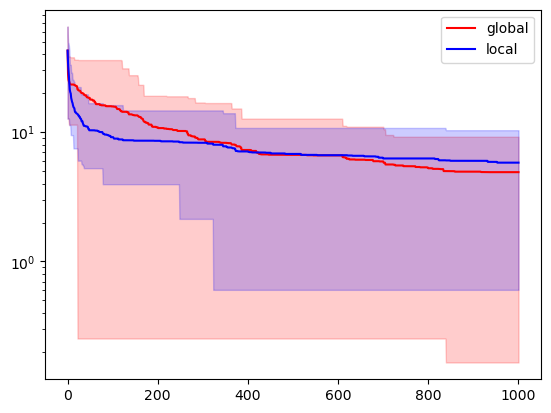

In [55]:
results1 = experiment(31, rastrigin, 0.2, 0.8)
plt.plot(results1.mean(axis=0), "r", label="global")
plt.fill_between(np.arange(results1.shape[1]), np.min(results1, axis=0), np.max(results1, axis=0), color="r", alpha=0.2)

results2 = experiment(31, rastrigin, 0.8, 0.2)
plt.plot(results2.mean(axis=0), "b", label="local")
plt.fill_between(np.arange(results2.shape[1]), np.min(results2, axis=0), np.max(results2, axis=0), color="b", alpha=0.2)

plt.legend()
plt.semilogy()